

---

# Poker Hand Classification with Explainable AI

Using Decision Tree and Neural Network Models

This script implements a machine learning pipeline that loads and preprocesses the UCI Poker Hand dataset, performs exploratory data analysis (EDA) with visualizations, trains a decision tree and a neural network model, and evaluates their performance.


Author: Thomas Weaver

---

In [1]:
# Import necessary libraries
import pandas as pd         # for data manipulation
import numpy as np          # for numerical operations
import matplotlib.pyplot as plt  # for data visualization
import seaborn as sns       # for enhanced data visualization

# For data preprocessing and model evaluation
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.metrics import classification_report, confusion_matrix

# Machine Learning models
from sklearn.tree import DecisionTreeClassifier
from sklearn.neural_network import MLPClassifier

 ---
# 1. Install ucimlrepo and Import the Poker Hand Dataset
---

In [2]:
!pip install ucimlrepo

# After the installation completes, import the fetch_ucirepo function
from ucimlrepo import fetch_ucirepo

# Fetch the Poker Hand dataset by specifying the ID = 158
poker_hand = fetch_ucirepo(id=158)

# Extract features (X) and targets (y) as pandas DataFrames/Series
X = poker_hand.data.features
y = poker_hand.data.targets

# Print metadata and variable information for reference
print("==== Dataset Metadata ====")
print(poker_hand.metadata)
print("\n==== Variable Information ====")
print(poker_hand.variables)

# Display the first few rows of features and the target
print("\nFirst 5 rows of feature data:")
print(X.head())
print("\nFirst 5 target values:")
print(y.head())

==== Dataset Metadata ====
{'uci_id': 158, 'name': 'Poker Hand', 'repository_url': 'https://archive.ics.uci.edu/dataset/158/poker+hand', 'data_url': 'https://archive.ics.uci.edu/static/public/158/data.csv', 'abstract': 'Purpose is to predict poker hands', 'area': 'Games', 'tasks': ['Classification'], 'characteristics': ['Multivariate'], 'num_instances': 1025010, 'num_features': 10, 'feature_types': ['Categorical', 'Integer'], 'demographics': [], 'target_col': ['CLASS'], 'index_col': None, 'has_missing_values': 'no', 'missing_values_symbol': None, 'year_of_dataset_creation': 2002, 'last_updated': 'Sat Mar 09 2024', 'dataset_doi': '10.24432/C5KW38', 'creators': ['Robert Cattral', 'Franz Oppacher'], 'intro_paper': None, 'additional_info': {'summary': 'Each record is an example of a hand consisting of five playing cards drawn from a standard deck of 52. Each card is described using two attributes (suit and rank), for a total of 10 predictive attributes. There is one Class attribute that de

---
# 2. Exploratory Data Analysis (EDA)
---


==== Features DataFrame Info ====
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1025010 entries, 0 to 1025009
Data columns (total 10 columns):
 #   Column  Non-Null Count    Dtype
---  ------  --------------    -----
 0   S1      1025010 non-null  int64
 1   C1      1025010 non-null  int64
 2   S2      1025010 non-null  int64
 3   C2      1025010 non-null  int64
 4   S3      1025010 non-null  int64
 5   C3      1025010 non-null  int64
 6   S4      1025010 non-null  int64
 7   C4      1025010 non-null  int64
 8   S5      1025010 non-null  int64
 9   C5      1025010 non-null  int64
dtypes: int64(10)
memory usage: 78.2 MB

==== Summary Statistics of Features ====
                 S1            C1            S2            C2            S3  \
count  1.025010e+06  1.025010e+06  1.025010e+06  1.025010e+06  1.025010e+06   
mean   2.500695e+00  6.997861e+00  2.499841e+00  7.006295e+00  2.501100e+00   
std    1.117737e+00  3.743529e+00  1.118646e+00  3.744054e+00  1.118345e+00   
min    1.0

<ipython-input-3-7b18d731cfa6>:16: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='Class', data=df, palette="viridis")


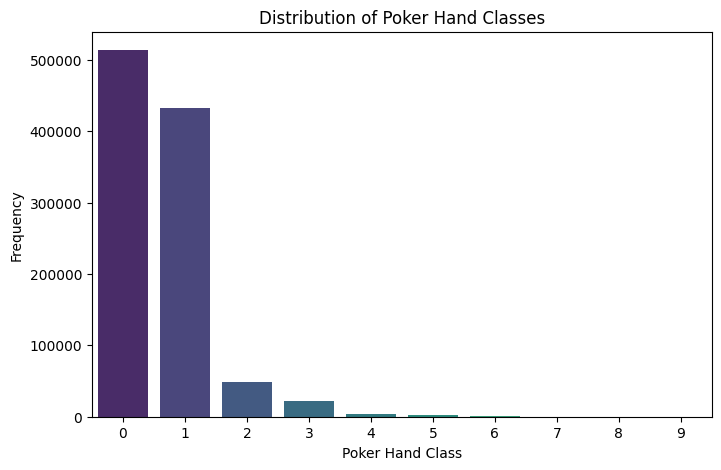

In [3]:
# Check basic info of the features
print("\n==== Features DataFrame Info ====")
X.info()

# Check summary statistics of numeric columns
print("\n==== Summary Statistics of Features ====")
print(X.describe())

# Combine X and y into a single DataFrame for convenience
# (Assuming the 'Class' column is your target)
df = X.copy()
df['Class'] = y

# Plot the distribution of the 'Class' column (poker hands)
plt.figure(figsize=(8, 5))
sns.countplot(x='Class', data=df, palette="viridis")
plt.title("Distribution of Poker Hand Classes")
plt.xlabel("Poker Hand Class")
plt.ylabel("Frequency")
plt.show()

# Examine any relevant correlations (especially card ranks if they are numeric)
# Adjust the code if your rank columns differ in naming
rank_columns = [col for col in df.columns if 'rank' in col.lower()]

if rank_columns:
    plt.figure(figsize=(10, 8))
    correlation_matrix = df[rank_columns].corr()
    sns.heatmap(correlation_matrix, annot=True, cmap="coolwarm")
    plt.title("Correlation Matrix for Card Ranks")
    plt.show()

---
# 3. Data Preprocessing
---

In [5]:
# Separate suits and ranks if available
# Adjust column names to match your dataset's suits & ranks columns
suit_columns = [col for col in X.columns if 'suit' in col.lower()]
rank_columns = [col for col in X.columns if 'rank' in col.lower()]

# Build a ColumnTransformer to handle categorical vs. numeric data
preprocessor = ColumnTransformer(
    transformers=[
        ('suit', OneHotEncoder(), suit_columns),
        ('rank', MinMaxScaler(), rank_columns)
    ],
    remainder='passthrough'  # if there are any other columns
)

# Apply the preprocessing to features
X_preprocessed = preprocessor.fit_transform(X)

print("\nShape of features after preprocessing:", X_preprocessed.shape)

# Split the data into training and test sets
# We use stratify=y to maintain class distribution in both sets
X_train, X_test, y_train, y_test = train_test_split(
    X_preprocessed, y, test_size=0.2, random_state=42, stratify=y
)

print("Training set size:", X_train.shape[0])
print("Testing set size:", X_test.shape[0])


Shape of features after preprocessing: (1025010, 10)
Training set size: 820008
Testing set size: 205002


---
 4. Model 1: Decision Tree Classifier
---



=== Decision Tree Classifier Evaluation ===
              precision    recall  f1-score   support

           0       0.74      0.73      0.74    102740
           1       0.62      0.63      0.62     86619
           2       0.30      0.30      0.30      9766
           3       0.32      0.34      0.33      4327
           4       0.30      0.29      0.30       796
           5       0.14      0.18      0.16       410
           6       0.11      0.12      0.11       292
           7       0.02      0.02      0.02        47
           8       0.00      0.00      0.00         3
           9       0.00      0.00      0.00         2

    accuracy                           0.66    205002
   macro avg       0.25      0.26      0.26    205002
weighted avg       0.66      0.66      0.66    205002



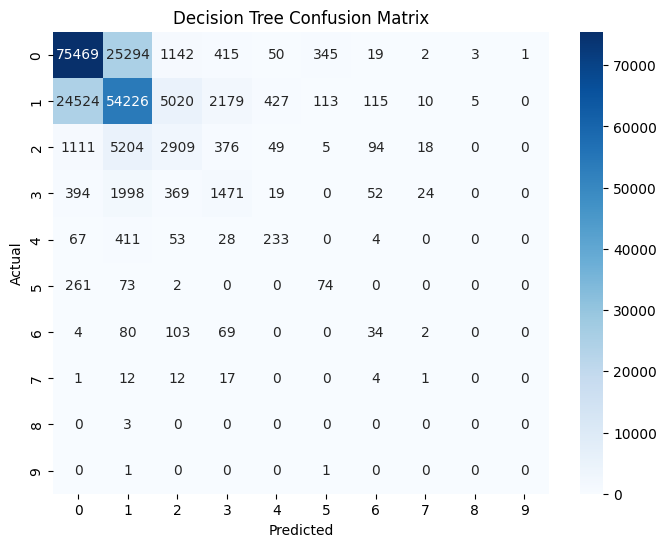

In [6]:
# Initialize and train the Decision Tree
decision_tree = DecisionTreeClassifier(
    criterion='gini',
    class_weight='balanced',  # helps with class imbalance
    random_state=42
)
decision_tree.fit(X_train, y_train)

# Predict and evaluate
y_pred_dt = decision_tree.predict(X_test)

print("\n=== Decision Tree Classifier Evaluation ===")
print(classification_report(y_test, y_pred_dt))

# Confusion matrix
conf_matrix_dt = confusion_matrix(y_test, y_pred_dt)
plt.figure(figsize=(8, 6))
sns.heatmap(conf_matrix_dt, annot=True, fmt="d", cmap="Blues")
plt.title("Decision Tree Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

---
# 5. Model 2: Neural Network (MLPClassifier)
---

/usr/local/lib/python3.11/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:1124: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
/usr/local/lib/python3.11/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:698: UserWarning: Training interrupted by user.
  warnings.warn("Training interrupted by user.")



=== Neural Network (MLPClassifier) Evaluation ===
              precision    recall  f1-score   support

           0       0.94      1.00      0.97    102740
           1       0.96      0.94      0.95     86619
           2       0.73      0.61      0.66      9766
           3       0.82      0.49      0.62      4327
           4       0.46      0.08      0.13       796
           5       0.98      0.95      0.97       410
           6       0.33      0.00      0.01       292
           7       0.00      0.00      0.00        47
           8       0.00      0.00      0.00         3
           9       0.00      0.00      0.00         2

    accuracy                           0.94    205002
   macro avg       0.52      0.41      0.43    205002
weighted avg       0.93      0.94      0.93    205002



/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


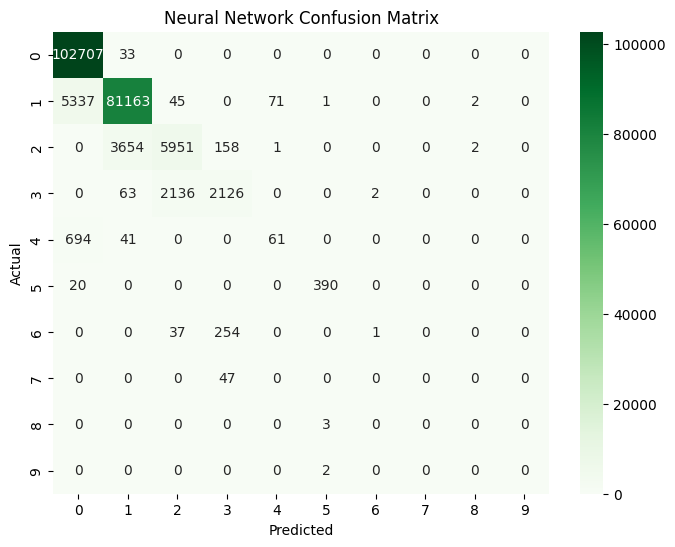

In [7]:
# Instantiate the MLP
mlp = MLPClassifier(
    hidden_layer_sizes=(50,),
    activation='relu',
    solver='adam',
    max_iter=300,
    early_stopping=True,
    random_state=42
)

# Train on the same split you used for the Decision Tree
mlp.fit(X_train, y_train)

# Predict & evaluate
y_pred_mlp = mlp.predict(X_test)

print("\n=== Neural Network (MLPClassifier) Evaluation ===")
print(classification_report(y_test, y_pred_mlp))

# Plot confusion matrix
conf_mlp = confusion_matrix(y_test, y_pred_mlp)
plt.figure(figsize=(8, 6))
sns.heatmap(conf_mlp, annot=True, fmt='d', cmap='Greens')
plt.title("Neural Network Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

---
# 6. Comparison and Observations
---

. Overall accuracy and weighted performance

    Decision Tree: ∼ 66 % accuracy, weighted-avg F₁ ≈ 0.66

    MLPClassifier: ∼ 94 % accuracy, weighted-avg F₁ ≈ 0.93

The neural net is dramatically better at picking up the two most common classes (No-Pair and One-Pair), which together make up ∼ 90 % of your hands.
2. Macro-averaged scores reveal class imbalance issues

    Decision Tree macro F₁ ≈ 0.26

    MLP macro F₁ ≈ 0.43

Even though the MLP’s macro-F₁ is almost twice as high, both models perform poorly on the rare hand types (Classes 4–9). In fact, the MLP entirely misses Classes 7–9, and has almost zero recall on Class 6.

The MLP makes huge gains on Classes 0–3 and Flushes (Class 5), but actually worsens on Straights (Class 4) and Full Houses (Class 6).

The Decision Tree was somewhat more “even” on mid-frequency classes (2–4) but plateaued at ~30 % F₁.

3. Confusion-matrix patterns

    MLP almost never confuses No-Pair & One-Pair, while the tree splits them heavily.

    Both models collapse the rare categories into the two major ones.